## **Importing Required Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Loading the dataset**

In [ ]:
df = pd.read_csv('/content/sales_data_csv - Sheet1.csv')

Reviewing the column headers

In [ ]:
df.head(10)

,Date,Product,Category,Units Sold,Unit Price,Total Revenue
0,2025-01-01,Laptop,Electronics,5,55000,275000
1,2025-01-01,Mouse,Electronics,12,500,6000
2,2025-01-02,T-Shirt,Clothing,20,400,8000
3,2025-01-02,Laptop,Electronics,3,55000,165000
4,2025-01-03,Headphones,Electronics,7,2500,17500
5,2025-01-03,Jeans,Clothing,10,1200,12000
6,2025-01-04,Jacket,Clothing,4,2500,10000
7,2025-01-04,Mouse,Electronics,15,500,7500
8,2025-01-05,Laptop,Electronics,2,55000,110000
9,2025-01-05,Headphones,Electronics,6,2500,15000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           10 non-null     object
 1   Product        10 non-null     object
 2   Category       10 non-null     object
 3   Units Sold     10 non-null     int64 
 4   Unit Price     10 non-null     int64 
 5   Total Revenue  10 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 612.0+ bytes


Getting summary overview

In [ ]:
df.describe()

,Units Sold,Unit Price,Total Revenue
count,10.000000,10.000000,10.000000
mean,8.400000,17510.000000,62600.000000
std,5.796551,25884.034118,92312.211784
min,2.000000,400.000000,6000.000000
25%,4.250000,675.000000,8500.000000
50%,6.500000,2500.000000,13500.000000
75%,11.500000,41875.000000,86875.000000
max,20.000000,55000.000000,275000.000000


Checking missing value

In [ ]:
df.isnull().sum()

,0
Date,0
Product,0
Category,0
Units Sold,0
Unit Price,0
Total Revenue,0


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           10 non-null     datetime64[ns]
 1   Product        10 non-null     object        
 2   Category       10 non-null     object        
 3   Units Sold     10 non-null     int64         
 4   Unit Price     10 non-null     int64         
 5   Total Revenue  10 non-null     int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 612.0+ bytes


Adding new calculated column

In [ ]:
df["Cost Price"] = df["Unit Price"] * 0.75 #Assume 25% profit margin
df["Profit"] = df["Total Revenue"] - df["Cost Price"] * df["Units Sold"]

In [ ]:
df.head()

,Date,Product,Category,Units Sold,Unit Price,Total Revenue,Cost Price,Profit
0,2025-01-01,Laptop,Electronics,5,55000,275000,41250.0,68750.0
1,2025-01-01,Mouse,Electronics,12,500,6000,375.0,1500.0
2,2025-01-02,T-Shirt,Clothing,20,400,8000,300.0,2000.0
3,2025-01-02,Laptop,Electronics,3,55000,165000,41250.0,41250.0
4,2025-01-03,Headphones,Electronics,7,2500,17500,1875.0,4375.0


# **Group analysis**

**Total Revenue by category**

In [ ]:
df.groupby('Category')['Total Revenue'].sum().sort_values(ascending=False)

,Total Revenue
Category,
Electronics,596000
Clothing,30000


**Sales as per Product**

In [ ]:
df.groupby('Product')['Units Sold'].sum().sort_values(ascending=False)

,Units Sold
Product,
Mouse,27
T-Shirt,20
Headphones,13
Laptop,10
Jeans,10
Jacket,4


In [ ]:
df.groupby('Date')['Total Revenue'].sum().sort_values(ascending=False)

,Total Revenue
Date,
2025-01-01,281000
2025-01-02,173000
2025-01-05,125000
2025-01-03,29500
2025-01-04,17500


# **Visual analysis with Matplotlib**

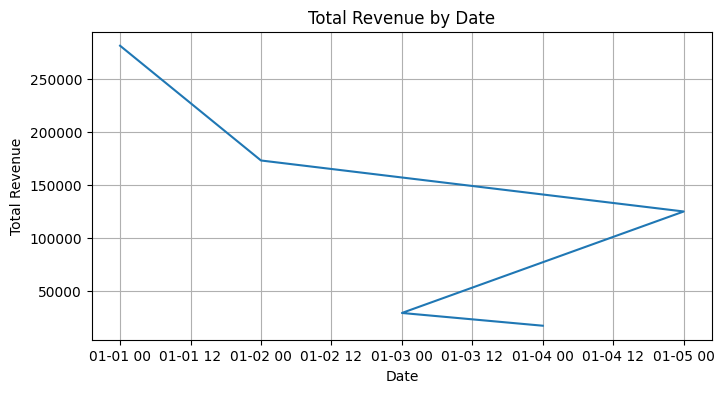

In [ ]:
df.groupby('Date')['Total Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,4))
plt.title('Total Revenue by Date')
plt.plot(df.groupby('Date')['Total Revenue'].sum().sort_values(ascending=False))
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.grid()
plt.show()

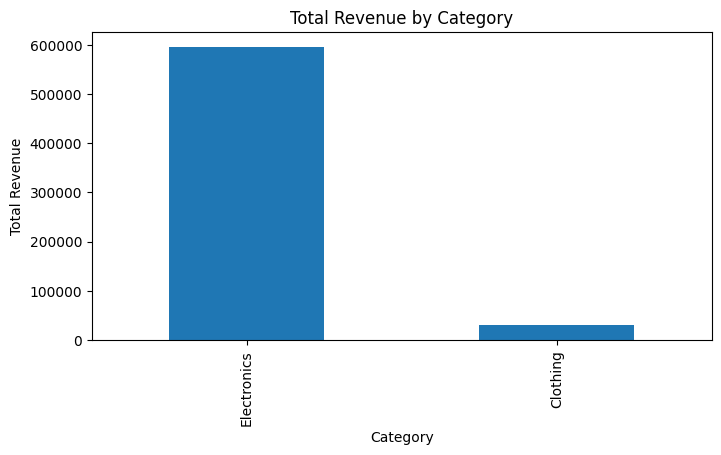

In [ ]:
category_rev = df.groupby('Category')['Total Revenue'].sum().sort_values(ascending=False)


plt.figure(figsize=(8,4))
plt.title('Total Revenue by Category')
category_rev.plot(kind='bar')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.show()

# **Relationship Plot using Seaborn**

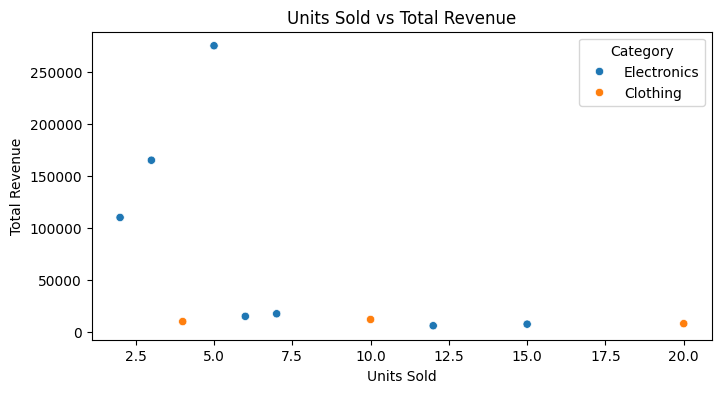

In [ ]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='Units Sold', y='Total Revenue', hue = "Category")
plt.title('Units Sold vs Total Revenue')
plt.show()